(statistics_as_gen_model)=
# Understanding regression through predictive modeling

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lithos import CategoricalPlot
import statsmodels.formula.api as smf
import statsmodels.api as sm

rng = np.random.default_rng(seed=42)

In [2]:
data = pd.read_csv(Path().cwd().parent/"data/stats/regression_as_generative.csv")
data["con_log"] = np.log10(data["consumption"])

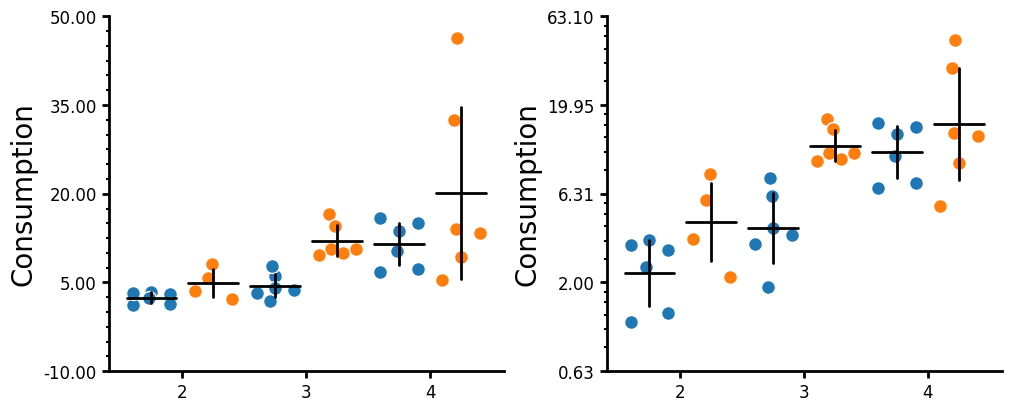

In [3]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4), layout="constrained")
plot = (
    CategoricalPlot(data)
    # .grouping(group="Cohort", subgroup="Sex", subgroup_order=["M, F"])
    .grouping(group="Cohort", subgroup="Sex", subgroup_order=["M", "F"])
    .plot_data(y="consumption", ylabel="Consumption")
    # .transform(ytransform="log10", back_transform_yticks=True)
    .jitter(markersize=10, width=0.6)
    .summary(barwidth=0.8, err_func="std")
    .axis(ydecimals=2)
    .axis_format(yminorticks=5)
    .plot(figure=fig, axes=ax[0])
)
plot = (
    CategoricalPlot(data)
    # .grouping(group="Cohort", subgroup="Sex", subgroup_order=["M, F"])
    .grouping(group="Cohort", subgroup="Sex", subgroup_order=["M", "F"])
    .plot_data(y="consumption", ylabel="Consumption")
    .transform(ytransform="log10", back_transform_yticks=True)
    .jitter(markersize=10, width=0.6)
    .summary(barwidth=0.8, err_func="std")
    .axis(ydecimals=2)
    .axis_format(yminorticks=5)
    .plot(figure=fig, axes=ax[1])
)

Non-normalized consumption

In [4]:
formula = "consumption ~ C(Cohort, Diff) + C(Sex, Sum)"
rawmodel = smf.ols(formula, data=data).fit()
print(rawmodel.summary())

                            OLS Regression Results                            
Dep. Variable:            consumption   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     8.225
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           0.000384
Time:                        11:04:55   Log-Likelihood:                -112.44
No. Observations:                  34   AIC:                             232.9
Df Residuals:                      30   BIC:                             239.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                9.3899 

Log model

In [5]:
formula = "con_log ~ C(Cohort, Diff) + C(Sex, Sum)"
logmodel = smf.rlm(formula, data=data, M=sm.robust.norms.HuberT()).fit()
print(logmodel.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:                con_log   No. Observations:                   34
Model:                            RLM   Df Residuals:                       30
Method:                          IRLS   Df Model:                            3
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Fri, 24 Jul 2026                                         
Time:                        11:04:55                                         
No. Iterations:                    15                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.8248 

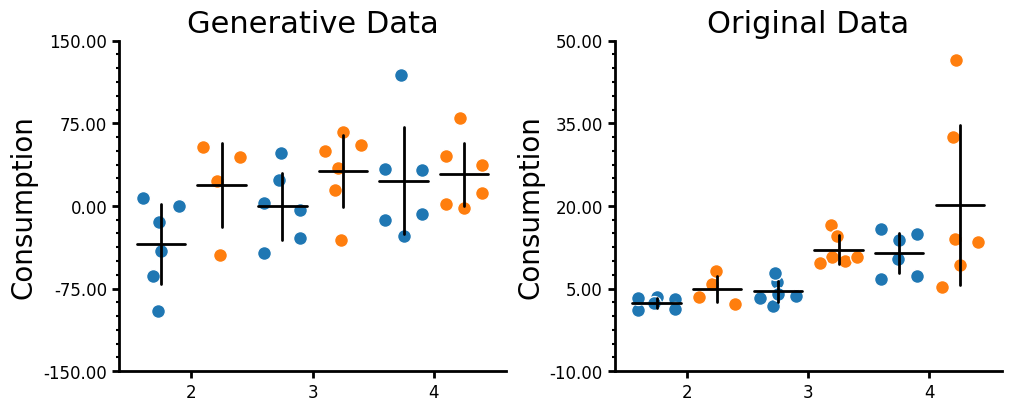

In [6]:
pred_probs = rawmodel.predict(data)
raw_model_predictions = pd.DataFrame({"predicted": rng.normal(loc=pred_probs, scale=rawmodel.scale), "Cohort": data["Cohort"], "Sex":data["Sex"], "Tx": data["Tx"]})
fig, ax = plt.subplots(ncols=2, figsize=(10,4), layout="constrained")
plot = (
    CategoricalPlot(raw_model_predictions)
    .grouping(group="Cohort", subgroup="Sex", subgroup_order=["M", "F"])
    .plot_data(y="predicted", ylabel="Consumption", title="Generative Data")
    .jitter(markersize=10, width=0.6)
    .summary(barwidth=0.8, err_func="std")
    .axis(ydecimals=2)
    .axis_format(yminorticks=5)
    .plot(figure=fig, axes=ax[0])
)
plot = (
    CategoricalPlot(data)
    .grouping(group="Cohort", subgroup="Sex", subgroup_order=["M", "F"])
    .plot_data(y="consumption", ylabel="Consumption", title="Original Data")
    .jitter(markersize=10, width=0.6)
    .summary(barwidth=0.8, err_func="std")
    .axis(ydecimals=2)
    .axis_format(yminorticks=5)
    .plot(figure=fig, axes=ax[1])
)

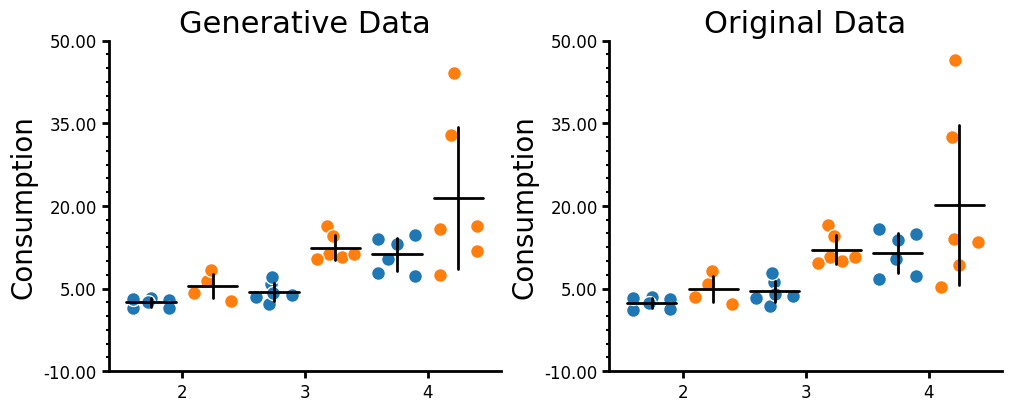

In [7]:
pred_probs = logmodel.predict(data)
logmodel_predictions = pd.DataFrame({"consumption": 10**rng.normal(loc=pred_probs, scale=logmodel.scale), "Cohort": data["Cohort"], "Sex":data["Sex"], "Tx": data["Tx"]})
fig, ax = plt.subplots(ncols=2, figsize=(10,4), layout="constrained")
plot = (
    CategoricalPlot(logmodel_predictions)
    .grouping(group="Cohort", subgroup="Sex", subgroup_order=["M", "F"])
    .plot_data(y="consumption", ylabel="Consumption",  title="Generative Data")
    .jitter(markersize=10, width=0.6)
    .summary(barwidth=0.8, err_func="std")
    .axis(ydecimals=2)
    .axis_format(yminorticks=5)
    .plot(figure=fig, axes=ax[0])
)
plot = (
    CategoricalPlot(data)
    .grouping(group="Cohort", subgroup="Sex", subgroup_order=["M", "F"])
    .plot_data(y="consumption", ylabel="Consumption", title="Original Data")
    .jitter(markersize=10, width=0.6)
    .summary(barwidth=0.8, err_func="std")
    .axis(ydecimals=2)
    .axis_format(yminorticks=5)
    .plot(figure=fig, axes=ax[1])
)